# Fixing the evaluation function and re-saving perfs

In [1]:
import numpy as np 
import sys
from matplotlib import pyplot as plt
import matplotlib.patches as patches
import scipy
import os
import importlib
import pandas as pd

sys.path.append('/home/nuttidalab/Documents/renee/spikeRNN/analysis/utils')
import load_data as ld 
import lfp_utils as lu
import rate_neuron_utils as rn
from bootstrap_method import *

2026-06-29 14:17:19.742221: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-06-29 14:17:19.750199: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:485] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2026-06-29 14:17:19.758820: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:8454] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2026-06-29 14:17:19.761491: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1452] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2026-06-29 14:17:19.768549: I tensorflow/core/platform/cpu_feature_guar

In [2]:
# find all bhv_dict files in the directory and subdirectories

all_models_dir = '/home/nuttidalab/Documents/renee/sternberg/multiload_1_2_3'

import glob
bhv_dict_files = glob.glob(os.path.join(all_models_dir, '**', 'bhv_dict_*.pkl'), recursive=True)

print(f"Found {len(bhv_dict_files)} bhv_dict files.")
print("Files:")
for file in bhv_dict_files:
    print(file)

Found 265 bhv_dict files.
Files:
/home/nuttidalab/Documents/renee/sternberg/multiload_1_2_3/Task_sternberg_N_1000_Jitter_5_3_2026_06_07_151225/bhv_dict_delay150_balance_match.pkl
/home/nuttidalab/Documents/renee/sternberg/multiload_1_2_3/Task_sternberg_N_1000_Jitter_5_3_2026_06_07_151225/bhv_dict_delay150_balance_stims.pkl
/home/nuttidalab/Documents/renee/sternberg/multiload_1_2_3/Task_sternberg_N_1000_Jitter_5_3_2026_06_07_151225/bhv_dict_delay200_balance_stims.pkl
/home/nuttidalab/Documents/renee/sternberg/multiload_1_2_3/Task_sternberg_N_1000_Jitter_5_3_2026_06_07_151225/bhv_dict_delay200_balance_match.pkl
/home/nuttidalab/Documents/renee/sternberg/multiload_1_2_3/Task_sternberg_N_1000_Jitter_5_3_2026_06_07_042058/bhv_dict_delay150_balance_match.pkl
/home/nuttidalab/Documents/renee/sternberg/multiload_1_2_3/Task_sternberg_N_1000_Jitter_5_3_2026_06_07_042058/bhv_dict_delay150_balance_stims.pkl
/home/nuttidalab/Documents/renee/sternberg/multiload_1_2_3/Task_sternberg_N_1000_Jitter_5_3

In [3]:
# load behavioral data with the filename

import pickle as pk

def load_bhv_dict(file_path):
    with open(file_path, 'rb') as f:
        bhv_dict = pk.load(f)
    
    trial_labels = np.array(bhv_dict['trial_type'])
    trial_perfs = bhv_dict['perf'].squeeze()
    trial_outputs = bhv_dict['outputs']

    return trial_labels, trial_perfs, trial_outputs

In [4]:
# regenerate trial_perfs from trial_outputs

def recalc_trialperfs(trial_labels, trial_outputs, trial_perfs, settings):
    """
    Recalculate trial_perfs from trial_outputs using a threshold.
    """
    threshold=0.7

    trial_perfs_recalc = np.zeros_like(trial_perfs)
    for i, (labels, outputs) in enumerate(zip(trial_labels, trial_outputs)):
        load = int(labels[0])
        label = int(labels[1])
        resp_onset = int(settings["stim_on"] + load * settings["stim_dur"] + 
                         settings["delay"] + settings["stim_dur"] + 10)
        if label == 1:
            trial_perfs_recalc[i] = int(np.max(outputs[resp_onset:]) > threshold)
        else:
            trial_perfs_recalc[i] = int(np.min(outputs[resp_onset:]) < -threshold)

    print(f"Original trial_perfs: {np.mean(trial_perfs):.3f}")
    print(f"Recalculated trial_perfs: {np.mean(trial_perfs_recalc):.3f}")

    return trial_perfs_recalc

### test that the new function works

In [9]:
# for loop

dif_perfs = []
prev_means = []
new_means = []
for i, bhv_filepath in enumerate(bhv_dict_files):
    print(f"Processing file {i+1}/{len(bhv_dict_files)}: {bhv_filepath}")
    trial_labels, trial_perfs, trial_outputs = load_bhv_dict(bhv_filepath)
    
    # Load settings from the corresponding settings file
    settings_filepath = bhv_filepath.replace('bhv_dict', 'settings_dict')
    if os.path.exists(settings_filepath):
        with open(settings_filepath, 'rb') as f:
            settings = pk.load(f)
    else:
        print(f"Settings file not found for {bhv_filepath}. Skipping.")
        continue
    
    # Recalculate trial_perfs
    trial_perfs_recalc = recalc_trialperfs(trial_labels, trial_outputs, trial_perfs, settings)
    
    # check how many trial_perfs are different
    num_different = np.sum(trial_perfs != trial_perfs_recalc)
    dif_perfs.append(num_different)
    prev_means.append(np.mean(trial_perfs))
    new_means.append(np.mean(trial_perfs_recalc))
    
    # Save the recalculated trial_perfs back to the bhv_dict
    # with open(bhv_filepath, 'rb') as f:
    #     bhv_dict = pk.load(f)
    
    # bhv_dict['perf'] = trial_perfs_recalc
    
    # with open(bhv_filepath, 'wb') as f:
    #     pk.dump(bhv_dict, f)
    
    # print(f"Updated trial_perfs saved for {bhv_filepath}.")

Processing file 1/265: /home/nuttidalab/Documents/renee/sternberg/multiload_1_2_3/Task_sternberg_N_1000_Jitter_5_3_2026_06_07_151225/bhv_dict_delay150_balance_match.pkl
Original trial_perfs: 0.773
Recalculated trial_perfs: 0.770
Processing file 2/265: /home/nuttidalab/Documents/renee/sternberg/multiload_1_2_3/Task_sternberg_N_1000_Jitter_5_3_2026_06_07_151225/bhv_dict_delay150_balance_stims.pkl
Original trial_perfs: 0.677
Recalculated trial_perfs: 0.665
Processing file 3/265: /home/nuttidalab/Documents/renee/sternberg/multiload_1_2_3/Task_sternberg_N_1000_Jitter_5_3_2026_06_07_151225/bhv_dict_delay200_balance_stims.pkl
Original trial_perfs: 0.546
Recalculated trial_perfs: 0.527
Processing file 4/265: /home/nuttidalab/Documents/renee/sternberg/multiload_1_2_3/Task_sternberg_N_1000_Jitter_5_3_2026_06_07_151225/bhv_dict_delay200_balance_match.pkl
Original trial_perfs: 0.663
Recalculated trial_perfs: 0.647
Processing file 5/265: /home/nuttidalab/Documents/renee/sternberg/multiload_1_2_3/Ta

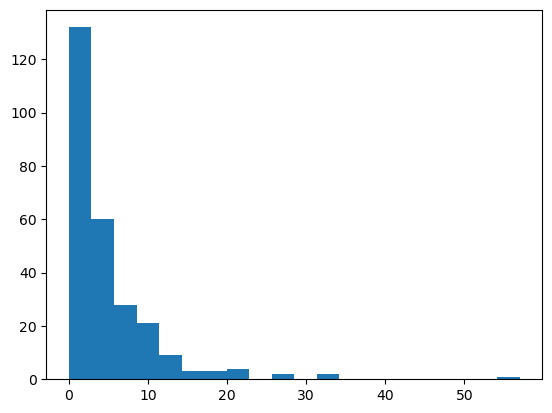

In [10]:
# plot how many are different

plt.hist(dif_perfs, bins=20);

/tmp/ipykernel_841155/602542327.py:4: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([prev_means, new_means], labels=['Original', 'Recalculated'])


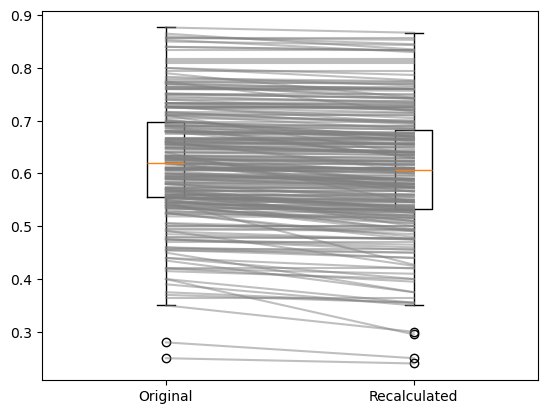

In [11]:
# plot mean differences as boxplots

plt.figure()
plt.boxplot([prev_means, new_means], labels=['Original', 'Recalculated'])
# plot gray lines
for i in range(len(prev_means)):
    plt.plot([1, 2], [prev_means[i], new_means[i]], color='gray', alpha=0.5)

In [12]:
# how many improved vs got worse

improved = np.sum(np.array(new_means) > np.array(prev_means))
worse = np.sum(np.array(new_means) < np.array(prev_means))

print(f"Number of models improved: {improved}")
print(f"Number of models got worse: {worse}")

Number of models improved: 0
Number of models got worse: 217


Trial 20: Load: 1, Label: -1, Response Onset: 310
Original perf: 1, Recalculated perf: 0


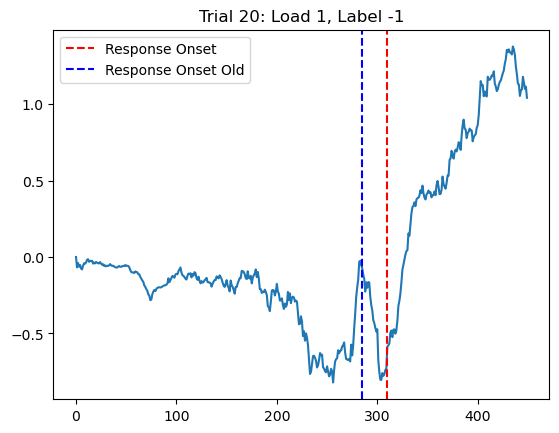

Trial 32: Load: 1, Label: -1, Response Onset: 310
Original perf: 1, Recalculated perf: 0


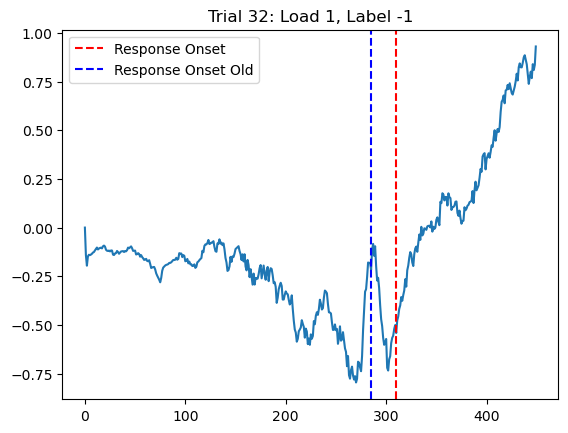

In [15]:
changed = np.where((trial_perfs != trial_perfs_recalc))[0]

for i in [changed[0], changed[1]]:
    load = int(trial_labels[i][0])
    label = int(trial_labels[i][1])
    resp_onset = int(settings["stim_on"] + load * settings["stim_dur"] + settings["delay"] + 
                     settings["stim_dur"] + 10)
    print(f"Trial {i}: Load: {load}, Label: {label}, Response Onset: {resp_onset}")
    print(f"Original perf: {trial_perfs[i]}, Recalculated perf: {trial_perfs_recalc[i]}")   
    plt.figure()
    plt.plot(trial_outputs[i]);
    plt.title(f'Trial {i}: Load {load}, Label {label}')
    plt.axvline(x=resp_onset, color='r', linestyle='--', label='Response Onset')
    plt.axvline(x=resp_onset - settings["stim_dur"], color='b', linestyle='--', label='Response Onset Old')
    plt.legend()
    plt.show()

### sanity check 1

In [ ]:
# sanity check -- using function originally used

def calc_trialperfs_old(trial_labels, trial_outputs, trial_perfs, settings):
    """
    Recalculate trial_perfs from trial_outputs using a threshold.
    """
    threshold=0.7

    stim_on = settings["stim_on"]
    stim_dur = settings["stim_dur"]
    delay = settings["delay"]
    # eval_start_load1 = stim_on + stim_dur + delay + stim_dur + 10
    # eval_start_load3 = stim_on + 3*stim_dur + delay + stim_dur + 10
    eval_start_load1 = stim_on + stim_dur + delay + 10
    eval_start_load3 = stim_on + 3*stim_dur + delay + 10

    trial_perfs_recalc = np.zeros_like(trial_perfs)
    for i, (labels, outputs) in enumerate(zip(trial_labels, trial_outputs)):
        # if labels[0] == 1:  # load 1
        #     eval_start = eval_start_load1
        # elif labels[0] == 3:  # load 3
        #     eval_start = eval_start_load3
        
        # if labels[1] == 1:  # match
        #     # if np.max(outputs[eval_start:eval_start+stim_dur]) > threshold:
        #     if np.max(outputs[eval_start:eval_start+50]) > threshold:
        #         trial_perfs_recalc[i] = 1
        # elif labels[1] == -1:  # mismatch
        #     # if np.min(outputs[eval_start:eval_start+stim_dur]) < threshold:
        #     if np.min(outputs[eval_start:eval_start+50]) < threshold:
        #         trial_perfs_recalc[i] = 1
                
        load = int(labels[0])
        label = int(labels[1])
        resp_onset = int(settings["stim_on"] + load * settings["stim_dur"] + settings["delay"] + 10)
        if label == 1:
            trial_perfs_recalc[i] = int(np.max(outputs[resp_onset:]) > threshold)
        else:
            trial_perfs_recalc[i] = int(np.min(outputs[resp_onset:]) < -threshold)

    print(f"Original trial_perfs: {np.mean(trial_perfs):.3f}")
    print(f"Recalculated trial_perfs: {np.mean(trial_perfs_recalc):.3f}")

    return trial_perfs_recalc

In [ ]:
# sanity check -- using function originally used

# for loop

dif_perfs = []
prev_means = []
new_means = []
for i, bhv_filepath in enumerate(bhv_dict_files):
    print(f"Processing file {i+1}/{len(bhv_dict_files)}: {bhv_filepath}")
    trial_labels, trial_perfs, trial_outputs = load_bhv_dict(bhv_filepath)
    
    # Load settings from the corresponding settings file
    settings_filepath = bhv_filepath.replace('bhv_dict', 'settings_dict')
    if os.path.exists(settings_filepath):
        with open(settings_filepath, 'rb') as f:
            settings = pk.load(f)
    else:
        print(f"Settings file not found for {bhv_filepath}. Skipping.")
        continue
    
    # Recalculate trial_perfs
    trial_perfs_recalc = calc_trialperfs_old(trial_labels, trial_outputs, trial_perfs, settings)
    
    # check how many trial_perfs are different
    num_different = np.sum(trial_perfs != trial_perfs_recalc)
    dif_perfs.append(num_different)
    prev_means.append(np.mean(trial_perfs))
    new_means.append(np.mean(trial_perfs_recalc))
    
    # Save the recalculated trial_perfs back to the bhv_dict
    # with open(bhv_filepath, 'rb') as f:
    #     bhv_dict = pk.load(f)
    
    # bhv_dict['perf'] = trial_perfs_recalc
    
    # with open(bhv_filepath, 'wb') as f:
    #     pk.dump(bhv_dict, f)
    
    # print(f"Updated trial_perfs saved for {bhv_filepath}.")

Processing file 1/265: /home/nuttidalab/Documents/renee/sternberg/multiload_1_2_3/Task_sternberg_N_1000_Jitter_5_3_2026_06_07_151225/bhv_dict_delay150_balance_match.pkl
Original trial_perfs: 0.773
Recalculated trial_perfs: 0.773
Processing file 2/265: /home/nuttidalab/Documents/renee/sternberg/multiload_1_2_3/Task_sternberg_N_1000_Jitter_5_3_2026_06_07_151225/bhv_dict_delay150_balance_stims.pkl
Original trial_perfs: 0.677
Recalculated trial_perfs: 0.677
Processing file 3/265: /home/nuttidalab/Documents/renee/sternberg/multiload_1_2_3/Task_sternberg_N_1000_Jitter_5_3_2026_06_07_151225/bhv_dict_delay200_balance_stims.pkl
Original trial_perfs: 0.546
Recalculated trial_perfs: 0.546
Processing file 4/265: /home/nuttidalab/Documents/renee/sternberg/multiload_1_2_3/Task_sternberg_N_1000_Jitter_5_3_2026_06_07_151225/bhv_dict_delay200_balance_match.pkl
Original trial_perfs: 0.663
Recalculated trial_perfs: 0.663
Processing file 5/265: /home/nuttidalab/Documents/renee/sternberg/multiload_1_2_3/Ta

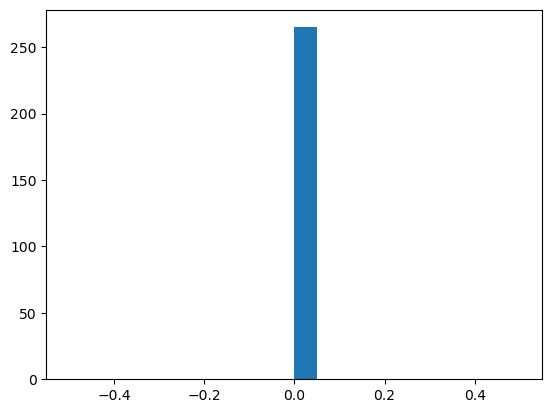

In [37]:
# plot how many are different

plt.hist(dif_perfs, bins=20);

In [32]:
np.where((trial_perfs != trial_perfs_recalc))[0]

array([20, 32])

In [33]:
print(trial_perfs[20], trial_perfs_recalc[20])
print(trial_perfs[32], trial_perfs_recalc[32])

1 0
1 0


Trial 20: Load: 1, Label: -1, Response Onset: 310


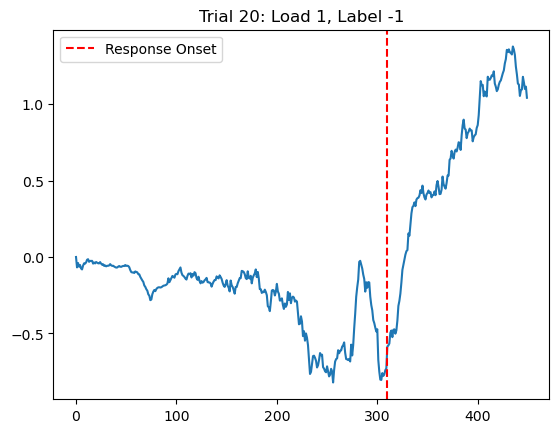

Trial 32: Load: 1, Label: -1, Response Onset: 310


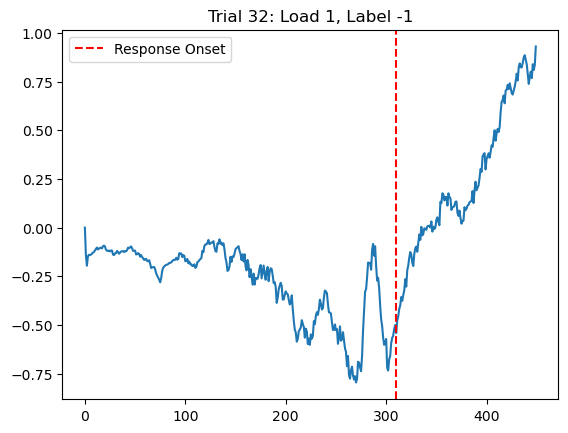

In [34]:
for i in [20, 32]:
    load = int(trial_labels[i][0])
    label = int(trial_labels[i][1])
    resp_onset = int(settings["stim_on"] + load * settings["stim_dur"] + settings["delay"] + settings["stim_dur"] + 10)
    print(f"Trial {i}: Load: {load}, Label: {label}, Response Onset: {resp_onset}")   
    plt.figure()
    plt.plot(trial_outputs[i]);
    plt.title(f'Trial {i}: Load {load}, Label {label}')
    plt.axvline(x=resp_onset, color='r', linestyle='--', label='Response Onset')
    plt.legend()
    plt.show()

### sanity check 2

using the same logic as original function

In [52]:
# sanity check -- using function originally used

def calc_trialperfs_old(trial_labels, trial_outputs, trial_perfs, settings):
    """
    Recalculate trial_perfs from trial_outputs using a threshold.
    """
    threshold=0.7

    stim_on = settings["stim_on"]
    stim_dur = settings["stim_dur"]
    delay = settings["delay"]
    # eval_start_load1 = stim_on + stim_dur + delay + stim_dur + 10
    # eval_start_load3 = stim_on + 3*stim_dur + delay + stim_dur + 10
    eval_start_load1 = stim_on + stim_dur + delay + 10
    eval_start_load2 = stim_on + 2*stim_dur + delay + 10
    eval_start_load3 = stim_on + 3*stim_dur + delay + 10

    trial_perfs_recalc = np.zeros_like(trial_perfs)
    for i, (labels, outputs) in enumerate(zip(trial_labels, trial_outputs)):
        if labels[0] == 1:  # load 1
            eval_start = eval_start_load1
        elif labels[0] == 2:  # load 2
            eval_start = eval_start_load2
        elif labels[0] == 3:  # load 3
            eval_start = eval_start_load3
        
        if labels[1] == 1:  # match
            # if np.max(outputs[eval_start:eval_start+stim_dur]) > threshold:
            if np.max(outputs[eval_start:]) > threshold:
                trial_perfs_recalc[i] = 1
        elif labels[1] == -1:  # mismatch
            # if np.min(outputs[eval_start:eval_start+stim_dur]) < threshold:
            if np.min(outputs[eval_start:]) < threshold:
                trial_perfs_recalc[i] = 1
                
        load = int(labels[0])
        label = int(labels[1])
        resp_onset = int(settings["stim_on"] + load * settings["stim_dur"] + settings["delay"] + 10)
        
        if eval_start != resp_onset:
            print(f"Warning: eval_start ({eval_start}) != resp_onset ({resp_onset}) for trial {i}")
            print(labels)
            print(load, label)
        if label == 1:
            trial_perfs_recalc[i] = int(np.max(outputs[resp_onset:]) > threshold)
        else:
            trial_perfs_recalc[i] = int(np.min(outputs[resp_onset:]) < -threshold)

    # print(f"Original trial_perfs: {np.mean(trial_perfs):.3f}")
    # print(f"Recalculated trial_perfs: {np.mean(trial_perfs_recalc):.3f}")

    return trial_perfs_recalc

In [53]:
# sanity check -- using same logic as original

# for loop

dif_perfs = []
prev_means = []
new_means = []
for i, bhv_filepath in enumerate(bhv_dict_files):
    print(f"Processing file {i+1}/{len(bhv_dict_files)}: {bhv_filepath}")
    trial_labels, trial_perfs, trial_outputs = load_bhv_dict(bhv_filepath)
    
    # Load settings from the corresponding settings file
    settings_filepath = bhv_filepath.replace('bhv_dict', 'settings_dict')
    if os.path.exists(settings_filepath):
        with open(settings_filepath, 'rb') as f:
            settings = pk.load(f)
    else:
        print(f"Settings file not found for {bhv_filepath}. Skipping.")
        continue
    
    # Recalculate trial_perfs
    trial_perfs_recalc = calc_trialperfs_old(trial_labels, trial_outputs, trial_perfs, settings)
    
    # check how many trial_perfs are different
    num_different = np.sum(trial_perfs != trial_perfs_recalc)
    dif_perfs.append(num_different)
    prev_means.append(np.mean(trial_perfs))
    new_means.append(np.mean(trial_perfs_recalc))
    
    # Save the recalculated trial_perfs back to the bhv_dict
    # with open(bhv_filepath, 'rb') as f:
    #     bhv_dict = pk.load(f)
    
    # bhv_dict['perf'] = trial_perfs_recalc
    
    # with open(bhv_filepath, 'wb') as f:
    #     pk.dump(bhv_dict, f)
    
    # print(f"Updated trial_perfs saved for {bhv_filepath}.")

Processing file 1/265: /home/nuttidalab/Documents/renee/sternberg/multiload_1_2_3/Task_sternberg_N_1000_Jitter_5_3_2026_06_07_151225/bhv_dict_delay150_balance_match.pkl
Processing file 2/265: /home/nuttidalab/Documents/renee/sternberg/multiload_1_2_3/Task_sternberg_N_1000_Jitter_5_3_2026_06_07_151225/bhv_dict_delay150_balance_stims.pkl
Processing file 3/265: /home/nuttidalab/Documents/renee/sternberg/multiload_1_2_3/Task_sternberg_N_1000_Jitter_5_3_2026_06_07_151225/bhv_dict_delay200_balance_stims.pkl
Processing file 4/265: /home/nuttidalab/Documents/renee/sternberg/multiload_1_2_3/Task_sternberg_N_1000_Jitter_5_3_2026_06_07_151225/bhv_dict_delay200_balance_match.pkl
Processing file 5/265: /home/nuttidalab/Documents/renee/sternberg/multiload_1_2_3/Task_sternberg_N_1000_Jitter_5_3_2026_06_07_042058/bhv_dict_delay150_balance_match.pkl
Processing file 6/265: /home/nuttidalab/Documents/renee/sternberg/multiload_1_2_3/Task_sternberg_N_1000_Jitter_5_3_2026_06_07_042058/bhv_dict_delay150_bala

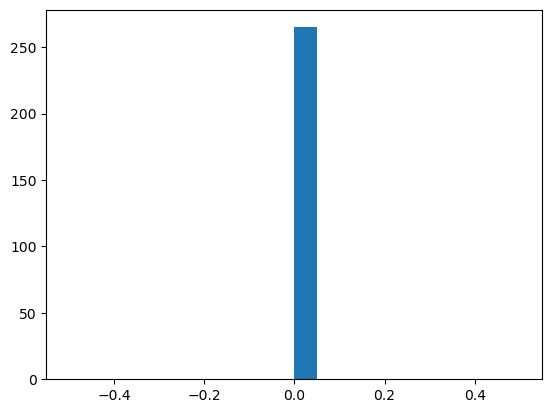

In [54]:
# plot how many are different

plt.hist(dif_perfs, bins=20);

## fix files since passed sanity checks

In [5]:
# for loop

for i, bhv_filepath in enumerate(bhv_dict_files):
    print(f"Processing file {i+1}/{len(bhv_dict_files)}: {bhv_filepath}")
    trial_labels, trial_perfs, trial_outputs = load_bhv_dict(bhv_filepath)
    
    # Load settings from the corresponding settings file
    settings_filepath = bhv_filepath.replace('bhv_dict', 'settings_dict')
    if os.path.exists(settings_filepath):
        with open(settings_filepath, 'rb') as f:
            settings = pk.load(f)
    else:
        print(f"Settings file not found for {bhv_filepath}. Skipping.")
        continue
    
    # Recalculate trial_perfs
    trial_perfs_recalc = recalc_trialperfs(trial_labels, trial_outputs, trial_perfs, settings)
    
    # # check how many trial_perfs are different
    # num_different = np.sum(trial_perfs != trial_perfs_recalc)
    # dif_perfs.append(num_different)
    # prev_means.append(np.mean(trial_perfs))
    # new_means.append(np.mean(trial_perfs_recalc))
    
    # Save the recalculated trial_perfs back to the bhv_dict
    with open(bhv_filepath, 'rb') as f:
        bhv_dict = pk.load(f)
    
    bhv_dict['perf'] = trial_perfs_recalc
    
    with open(bhv_filepath, 'wb') as f:
        pk.dump(bhv_dict, f)
    
    print(f"Updated trial_perfs saved for {bhv_filepath}.")

Processing file 1/265: /home/nuttidalab/Documents/renee/sternberg/multiload_1_2_3/Task_sternberg_N_1000_Jitter_5_3_2026_06_07_151225/bhv_dict_delay150_balance_match.pkl
Original trial_perfs: 0.773
Recalculated trial_perfs: 0.770
Updated trial_perfs saved for /home/nuttidalab/Documents/renee/sternberg/multiload_1_2_3/Task_sternberg_N_1000_Jitter_5_3_2026_06_07_151225/bhv_dict_delay150_balance_match.pkl.
Processing file 2/265: /home/nuttidalab/Documents/renee/sternberg/multiload_1_2_3/Task_sternberg_N_1000_Jitter_5_3_2026_06_07_151225/bhv_dict_delay150_balance_stims.pkl
Original trial_perfs: 0.677
Recalculated trial_perfs: 0.665
Updated trial_perfs saved for /home/nuttidalab/Documents/renee/sternberg/multiload_1_2_3/Task_sternberg_N_1000_Jitter_5_3_2026_06_07_151225/bhv_dict_delay150_balance_stims.pkl.
Processing file 3/265: /home/nuttidalab/Documents/renee/sternberg/multiload_1_2_3/Task_sternberg_N_1000_Jitter_5_3_2026_06_07_151225/bhv_dict_delay200_balance_stims.pkl
Original trial_perf